# Homework 2 - balancing, transformations, and dimensionality reduction (deadline 21. 12. 2025, 23:59)

In short, the main task is to play with balancing, binning, transformations, and dimensionality reduction to obtain the best results for the binary classification task.
  
> The instructions are not given in detail: It is up to you to come up with ideas on how to fulfill the particular tasks as best you can!

However, we **strongly recommend and require** the following:
* Follow the assignment step by step. Number each step.
* Properly comment on all your steps. Use Markdown cells and visualizations. Comments are evaluated for 2 points of the total, together with the final presentation of the solution. However, it is not desirable to write novels! 
* This task is timewise and computationally intensive. Do not leave it to the last minute.
* Most steps contain the number of features that should be treated. You can preprocess more features. However, it does not mean the teacher will give you more points. Focus on quality, not quantity.
* Hand in a notebook that has already been run (i.e., do not delete outputs before handing in).

## What are you supposed to do:

  1. Download the dataset [here](https://www.dropbox.com/s/aq08ytozfplb97b/data.csv?dl=0). Split the dataset into a train, validation, and test set and **use these parts correctly (!)** in the following steps.
  1. Choose at least one classification algorithm whose performance is to be improved in the following steps.
  1. Use at least two binning methods (on features of your choice, with your choice of parameters) and comment on their effects on classification performance. _I.e., one kind of classifier trained for each binning and a comparison of the effect of binning methods against each other._ _(4 points, depends on creativity)_ 
  1. Use at least two data balancing techniques on the correct part of the dataset and comment on its effects on classification performance. Focus on the comparison of methods between each other. _I.e., one type of classifier trained for each balancing and a comparison of the effect of balancing methods against each other._ **Just copied code from tutorial four will not be accepted.** _(6 points, depends on creativity)_
  1. Transform the features appropriately and prepare new ones (i.e., feature engineering) - focus on the increase in the model's performance (possibly in combination with further steps). _(5 points, depends on creativity)_ 
  1. Try to find some suitable subset of features - use at least two feature selection methods. Evaluate your choice on the validation set and discuss the influence. Do not use PCA (principal component analysis) in this step. Manual selection will not be accepted. _(4 points, depends on creativity)_
  1. Use PCA to reduce the dimensionality. Discuss the influence of the number of principal components. _(4 points)_
  1. Try to find the best combination of the previous steps and run final classification tests on the correct part of the dataset - first for the original data, second for the best-found combination of the previous preprocessing steps. Compare the results and discuss (give a comment, use graphs, and so on). _(5 points)_

All your steps, choices, and the following code **must be commented on!** For text comments (discussion, etc., not code comments), use **Markdown cells**. Comments are evaluated for _2 points_ together with the final presentation of the solution.

**If you do all this properly, you will obtain 30 points.**

### FAQ

* Select the appropriate metric to evaluate the classification results.
* In steps 2 and 3, you are comparing methods against each other, not their effect on unadjusted data. However, you can comment on that, too.
* You choose the subset of features only in step 2 because of the binning methods. In the other steps, you work with the whole dataset.

## Comments

  * Please follow the technical instructions from https://courses.fit.cvut.cz/NI-PDD/homeworks/index.html.
  * Methods that are more complex and were not shown during the tutorials are considered more creative and should be described in detail.
  * English is not compulsory.

  
## Data description

* The dataset can be downloaded [here](https://www.dropbox.com/s/aq08ytozfplb97b/data.csv?dl=0).
* The data are devoted to the binary classification task. The aim is to predict the probability that a driver will initiate an auto insurance claim next year.
* The target feature is called 'y' and signifies whether or not a claim was filed for that policyholder.
* To fulfill the task, one does not need to know the meaning of predictors.
* Predictors that belong to similar groupings are tagged as such in the feature names (e.g., ind, reg, car, calc). In addition, feature names include the postfix _bin_ to indicate binary features and the postfix _cat_ to indicate categorical features. Features without these designations are either continuous or ordinal. Values of -1 indicate that the feature was missing from the observation.
* While using [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), control the shuffling of data by random_state parameter. Do not use shuffle=False, probably never (can cause systematic error).

# UTILS

In [3]:
# imports
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import KBinsDiscretizer
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

# 1. Load the dataset
Load the data and split it into train, validation, and test set

- the data is split into 60% train, 20% validation, and 20% test set
- use stratified splitting to maintain the class distribution in each set

Data cleaning
- I removed features where is more then 50% missing values - only one feature 'xcar_03_cat'
- I removed constant features - which are there none

In [4]:
data_path = "data/data.csv"

# Load the data
data = pd.read_csv(data_path)

In [5]:
# data cleaning

# remove features where is missing values more then 50%
missing_threshold = 0.5
missing_fraction = (data == -1).mean()
cols_to_drop = missing_fraction[missing_fraction > missing_threshold].index.tolist()
data = data.drop(columns=cols_to_drop)
# print names of columns which are droped
print(f"Dropped {len(cols_to_drop)} columns with more than {missing_threshold*100}% missing values.")
# print names
print("Dropped columns:", cols_to_drop)


# remove constant features
nunique = data.nunique()
const_cols = nunique[nunique <= 1].index.tolist()
data = data.drop(columns=const_cols)
print(f"Dropped {len(const_cols)} constant columns.")

Dropped 1 columns with more than 50.0% missing values.
Dropped columns: ['xcar_03_cat']
Dropped 0 constant columns.


In [6]:
# split the data into train, validation, and test set
X = data.drop(columns=['y'])
y = data['y']

# set -1 in X to NaN for easier handling of missing values
X = X.replace(-1, np.nan)

# split the data into 60% train, 20% validation, and 20% test set
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# split the temp set into validation and test set
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

## Data exploration

In [4]:
# show basic info about the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 58 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   y             595212 non-null  int64  
 1   xind_01       595212 non-null  int64  
 2   xind_02_cat   595212 non-null  int64  
 3   xind_03       595212 non-null  int64  
 4   xind_04_cat   595212 non-null  int64  
 5   xind_05_cat   595212 non-null  int64  
 6   xind_06_bin   595212 non-null  int64  
 7   xind_07_bin   595212 non-null  int64  
 8   xind_08_bin   595212 non-null  int64  
 9   xind_09_bin   595212 non-null  int64  
 10  xind_10_bin   595212 non-null  int64  
 11  xind_11_bin   595212 non-null  int64  
 12  xind_12_bin   595212 non-null  int64  
 13  xind_13_bin   595212 non-null  int64  
 14  xind_14       595212 non-null  int64  
 15  xind_15       595212 non-null  int64  
 16  xind_16_bin   595212 non-null  int64  
 17  xind_17_bin   595212 non-null  int64  
 18  xind

In [5]:
# describe data
data.describe()

,y,xind_01,xind_02_cat,xind_03,xind_04_cat,xind_05_cat,xind_06_bin,xind_07_bin,xind_08_bin,xind_09_bin,...,xcalc_11,xcalc_12,xcalc_13,xcalc_14,xcalc_15_bin,xcalc_16_bin,xcalc_17_bin,xcalc_18_bin,xcalc_19_bin,xcalc_20_bin
count,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,...,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,0.036448,1.900378,1.358943,4.423318,0.416794,0.405188,0.393742,0.257033,0.163921,0.185304,...,5.441382,1.441918,2.872288,7.539026,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,0.187401,1.983789,0.664594,2.699902,0.493311,1.350642,0.488579,0.436998,0.370205,0.388544,...,2.332871,1.202963,1.694887,2.746652,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,0.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.000000,1.000000,3.000000,7.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,0.000000,3.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,7.000000,2.000000,4.000000,9.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.000000,7.000000,4.000000,11.000000,1.000000,6.000000,1.000000,1.000000,1.000000,1.000000,...,19.000000,10.000000,13.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
# show how many values are missing in each column where -1 indicates missing value
missing_values = (data == -1).sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 y                    0
xind_01              0
xind_02_cat        216
xind_03              0
xind_04_cat         83
xind_05_cat       5809
xind_06_bin          0
xind_07_bin          0
xind_08_bin          0
xind_09_bin          0
xind_10_bin          0
xind_11_bin          0
xind_12_bin          0
xind_13_bin          0
xind_14              0
xind_15              0
xind_16_bin          0
xind_17_bin          0
xind_18_bin          0
xreg_01              0
xreg_02              0
xreg_03         107772
xcar_01_cat        107
xcar_02_cat          5
xcar_03_cat     411231
xcar_04_cat          0
xcar_05_cat     266551
xcar_06_cat          0
xcar_07_cat      11489
xcar_08_cat          0
xcar_09_cat        569
xcar_10_cat          0
xcar_11_cat          0
xcar_11              5
xcar_12              1
xcar_13              0
xcar_14          42620
xcar_15              0
xcalc_01             0
xcalc_02             0
xcalc_03             0
xcalc_04             0
xc

# 2. Classifier choice
Choose at least one classification algorithm whose performance is to be improved in the following steps.

**Model**
for this task, we will use **Logistic Regression** as our classification algorithms
    - the choice is motivated by its simplicity and interpretability and also it comutes faster, then for example Random Forest

 
**Metrics**

In this task , we will use the following metrics to evaluate the performance of our models:
- ROC AUC score: This metric is suitable for binary classification tasks and provides a measure of the model's ability to distinguish between the two classes.
- Classification report: This report provides detailed metrics such as precision, recall, and F1-score for each class, which helps in understanding the model's performance on both positive and negative classes.
- Confusion matrix: This visualization helps in understanding the types of errors made by the model, such as false positives and false negatives.

## UTILS


In [12]:
# identify categorical and numerical features
cat_cols = [c for c in X.columns if c.endswith('_cat')]
bin_cols = [c for c in X.columns if c.endswith('_bin')]
num_cols = [c for c in X.columns if c not in cat_cols + bin_cols]

numeric_preprocess = Pipeline([
    ('impute',    SimpleImputer(strategy='median')),
    ('scaler',    StandardScaler())
])

categorical_preprocess = Pipeline([
    ('impute',    SimpleImputer(strategy='most_frequent')),
    ('onehot',    OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', numeric_preprocess, num_cols),
    ('bin', 'passthrough', bin_cols),
    ('cat', categorical_preprocess, cat_cols),
])

log_clf = LogisticRegression(
    n_jobs=-1,
    class_weight=None,
    solver='saga', 
    max_iter=1000,
)


In [13]:
def evaluate_pipeline(pipe, X_train, y_train, X_val, y_val, name="model"):
    """
    Fit the given pipeline, evaluate it on validation data,
    print metrics and show confusion matrix.
    """
    print(f"\n===== Evaluating: {name} =====")

    # fit
    pipe.fit(X_train, y_train)

    # predict
    y_val_pred_proba = pipe.predict_proba(X_val)[:, 1]
    y_val_pred = pipe.predict(X_val)

    # metrics
    auc = roc_auc_score(y_val, y_val_pred_proba)
    print(f"{name} ROC AUC: {auc:.4f}")
    print(classification_report(y_val, y_val_pred))

    # confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred)
    plt.title(f"Confusion matrix: {name}")
    plt.show()

    return pipe, y_val_pred_proba, y_val_pred

## Baseline experiment

In [7]:
baseline_pipe = Pipeline([
    ('preprocess', preprocess),
    ('clf', log_clf)
])

# evaluate baseline model
baseline_auc = evaluate_pipeline(
    baseline_pipe,
    X_train, y_train,
    X_val, y_val,
    name="Baseline Logistic Regression"
)

NameError: name 'preprocess' is not defined

From the baseline results we can see that our model can't properly classify the positive class. It never classifies any instance as positive. This is due to the class imbalance in the dataset, where the negative class is much more prevalent than the positive class.

# 3. Binning methods
Use at least two binning methods (on features of your choice, with your choice of parameters) and comment on their effects on classification performance. I.e., one kind of classifier trained for each binning and a comparison of the effect of binning methods against each other.

- We will apply equal-width binning to the all numerical, continues features in the dataset.
- We will use Sturges' formula to determine the number of bins: k = 1 + log2(n), where n is the number of observations.
    - which is approx. 20 bins for our dataset

Possible improvement:

- find for what features binning helps the most

In [7]:
# show me head of other columsn
print(X_train[num_cols].head())

        xind_01  xind_03  xind_14  xind_15  xreg_01  xreg_02   xreg_03  \
48913         2        3        0        7      0.9      1.2  1.543940   
360707        1        3        0        9      0.4      0.0  0.535607   
442580        6        7        0        6      0.6      0.2  0.642748   
63315         2        3        0        9      0.7      0.3  0.748749   
209390        0        3        1        4      0.8      0.2  0.494343   

        xcar_11   xcar_12   xcar_13  ...  xcalc_05  xcalc_06  xcalc_07  \
48913       3.0  0.424264  0.843081  ...         4         9         1   
360707      1.0  0.316070  0.598310  ...         2        10         2   
442580      1.0  0.316228  0.746811  ...         1         8         5   
63315       3.0  0.399875  0.680757  ...         1         9         4   
209390      2.0  0.316228  0.763947  ...         3        10         5   

        xcalc_08  xcalc_09  xcalc_10  xcalc_11  xcalc_12  xcalc_13  xcalc_14  
48913         10         4     

In [16]:
n_bins = 20

# select only other_cols for training and validation
X_train_num = X_train[num_cols]
X_val_num = X_val[num_cols]

## Basis result
- run the baseline logistic regression again for comparison only on the selected columns (numerical, continues features)


===== Evaluating: Baseline Logistic Regression on selected columns =====
Baseline Logistic Regression on selected columns ROC AUC: 0.6030
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042



C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


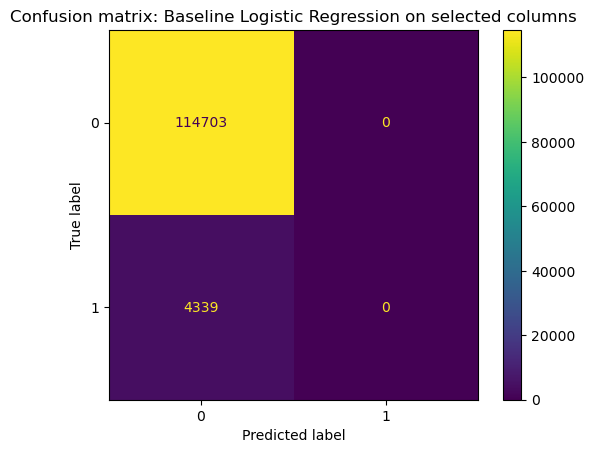

In [17]:

preprocess_basis = ColumnTransformer([
    ('num', numeric_preprocess, num_cols),
])

binning_basis_pipe = Pipeline([
    ('preprocess', preprocess_basis),
    ('clf', log_clf)
])

binning_basis_auc = evaluate_pipeline(
    binning_basis_pipe,
    X_train_num, y_train,
    X_val_num, y_val,
    name="Baseline Logistic Regression on selected columns"
)


## METHOD 1: Equal-width binning

### 20 bins


===== Evaluating: Binning Method 1: Equal-width binning =====


C:\tools\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Binning Method 1: Equal-width binning ROC AUC: 0.6136
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042



C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


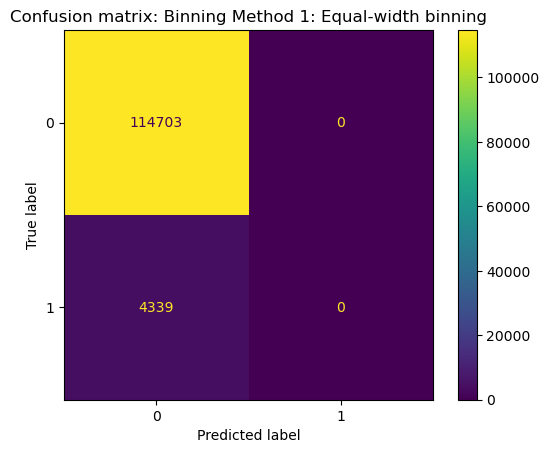

In [18]:

binning_A = ColumnTransformer([
    ('binned', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('bins', KBinsDiscretizer(n_bins=n_bins, encode='onehot-dense', strategy='uniform'))
    ]), num_cols)
])

binning_A_pipe = Pipeline([
    ('binning', binning_A),
    ('clf', log_clf)
])

# evaluate binning method 1
binning_A_auc = evaluate_pipeline(
    binning_A_pipe,
    X_train_num, y_train,
    X_val_num, y_val,
    name="Binning Method 1: Equal-width binning"
)

### 5 bins


===== Evaluating: Binning Method 1: Equal-width binning =====


C:\tools\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Binning Method 1: Equal-width binning ROC AUC: 0.5996
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042



C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


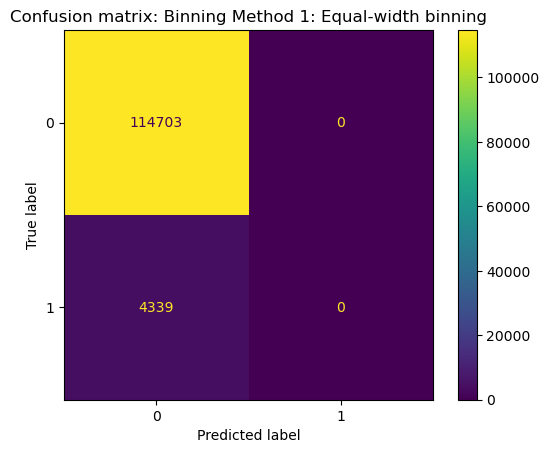

In [19]:

binning_A = ColumnTransformer([
    ('binned', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('bins', KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy='uniform'))
    ]), num_cols)
])

binning_A_pipe = Pipeline([
    ('binning', binning_A),
    ('clf', log_clf)
])

# evaluate binning method 1
binning_A_auc = evaluate_pipeline(
    binning_A_pipe,
    X_train_num, y_train,
    X_val_num, y_val,
    name="Binning Method 1: Equal-width binning"
)

## METHOD 2: Equal-frequency binning

### 20 bins


===== Evaluating: Binning Method 2: Equal-frequency binning =====


C:\tools\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\tools\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\tools\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\tools\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\tools\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: 

Binning Method 2: Equal-frequency binning ROC AUC: 0.6155
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042



C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


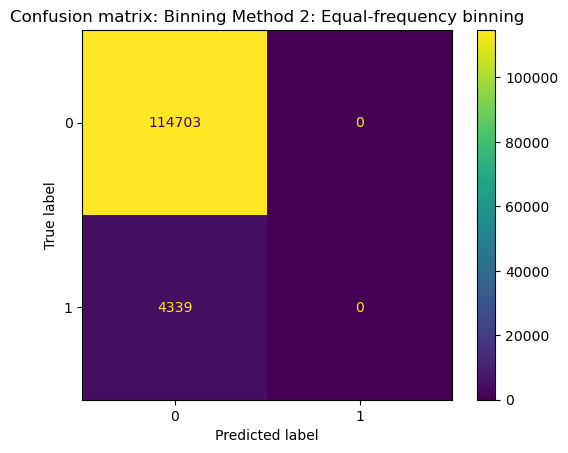

In [20]:
binning_B = ColumnTransformer([
    ('binned', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('bins', KBinsDiscretizer(n_bins=n_bins, encode='onehot-dense', strategy='quantile'))
    ]), num_cols)
])
binning_B_pipe = Pipeline([
    ('binning', binning_B),
    ('clf', log_clf)
])
# evaluate binning method 2
binning_B_auc = evaluate_pipeline(
    binning_B_pipe,
    X_train_num, y_train,
    X_val_num, y_val,
    name="Binning Method 2: Equal-frequency binning"
)

### 5 bins

In [21]:
binning_B = ColumnTransformer([
    ('binned', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('bins', KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy='quantile'))
    ]), num_cols)
])
binning_B_pipe = Pipeline([
    ('binning', binning_B),
    ('clf', log_clf)
])
# evaluate binning method 2
binning_B_auc = evaluate_pipeline(
    binning_B_pipe,
    X_train_num, y_train,
    X_val_num, y_val,
    name="Binning Method 2: Equal-frequency binning"
)


===== Evaluating: Binning Method 2: Equal-frequency binning =====


C:\tools\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\tools\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\tools\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\tools\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 7 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\tools\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: 

KeyboardInterrupt: 

## COMPARISON

**Baseline result**

```
==== Evaluating: Baseline Logistic Regression on selected columns =====
Baseline Logistic Regression on selected columns ROC AUC: 0.6030
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042
```


**20 bins**


```

===== Evaluating: Binning Method 1: Equal-width binning =====
Binning Method 1: Equal-width binning ROC AUC: 0.6136
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042
```

```

===== Evaluating: Binning Method 2: Equal-frequency binning =====

Binning Method 2: Equal-frequency binning ROC AUC: 0.6146
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042
```

**5 bins**

```

===== Evaluating: Binning Method 1: Equal-width binning =====
Binning Method 1: Equal-width binning ROC AUC: 0.5997
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042
```

```
Binning Method 2: Equal-frequency binning ROC AUC: 0.6080
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042
```


We can see an improvement in AUC values for using 20 or 5 bins when using Equal-width binning vs Equal-frequancy binning there is an improvement around 0,001 for Equal-frequency binning. 

With comparison with an baseline model, with 20 bins we can see an improvement around 0,01 in AUC values for both binning methods and with 5 bins we can see an decrease around 0,003 in AUC values or staying the same.

But for equal-frequency it looks like data are very much concantrated around same points so this methods doesnt do much for our result.

# 4. Balancing
Use at least two data balancing techniques on the correct part of the dataset and comment on its effects on classification performance. Focus on the comparison of methods between each other. I.e., one type of classifier trained for each balancing and a comparison of the effect of balancing methods against each other. 

I choose to use Random Oversampling and SMOTE+Tomek balancing, becouse oversampling tends to get better results for small dataset like ours. SMOTE+Tomek generally show the best results in most cases for unbalanced datasets with overlapping classes, which is ours and Random Oversampling is simple and effective method for balancing datasets used as baseline for comparison.

## METHOD 1: Random Oversampling


===== Evaluating: Balancing Method 1: Random Oversampling =====
Balancing Method 1: Random Oversampling ROC AUC: 0.6362
              precision    recall  f1-score   support

           0       0.98      0.63      0.76    114703
           1       0.06      0.58      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.52      0.60      0.43    119042
weighted avg       0.94      0.62      0.74    119042



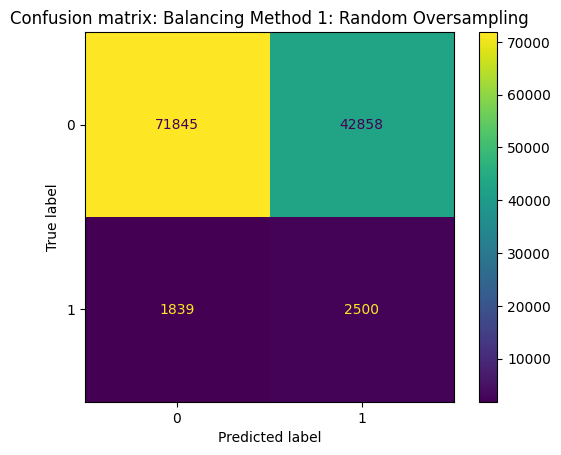

In [6]:

balancingA_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocess),
    ('over', RandomOverSampler(random_state=42)),
    ('clf', log_clf)
])

# evaluate balancing method 1
balancingA_auc = evaluate_pipeline(
    balancingA_pipeline,
    X_train, y_train,   
    X_val, y_val,
    name="Balancing Method 1: Random Oversampling"
)

## METHOD 2: SMOTE + Tomek Links
This takes a lot of time so, I decided not to use this method.

In [6]:
balancingB_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocess),
    ('smote_tomek', SMOTETomek(random_state=42)),
    ('clf', log_clf)
])
# evaluate balancing method 2
balancingB_auc = evaluate_pipeline(
    balancingB_pipeline,
    X_train, y_train,   
    X_val, y_val,
    name="Balancing Method 2: SMOTE + Tomek Links"
)


===== Evaluating: Balancing Method 2: SMOTE + Tomek Links =====


KeyboardInterrupt: 

## METHOD 3: SMOTE + Tomek Links with SMOTENC
This takes a lot of time so, I decided not to use this method.

In [1]:
from imblearn.over_sampling import SMOTENC

smote_nc = SMOTENC(
    categorical_features=[X.columns.get_loc(col) for col in cat_cols + bin_cols],
    random_state=42
)

smote_tomek_nc = SMOTETomek(smote=smote_nc, random_state=42)

balancingB_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocess),
    ('smote_tomek', smote_tomek_nc),
    ('clf', log_clf)
])
# evaluate balancing method 2
balancingB_auc = evaluate_pipeline(
    balancingB_pipeline,
    X_train, y_train,
    X_val, y_val,
    name="Balancing Method 2: SMOTE + Tomek Links"
)

NameError: name 'cat_cols' is not defined

## METHOD 4: SMOTENC
This takes a lot of memory so, I decided not to use this method.

In [33]:
from sklearn.preprocessing import OrdinalEncoder
# clean SMOTENC

from imblearn.over_sampling import SMOTENC

smote_nc = SMOTENC(
    categorical_features=[X.columns.get_loc(col) for col in cat_cols + bin_cols],
    random_state=42,
    k_neighbors=3,
    sampling_strategy=0.5,
)

categorical_preprocess_smotenc = Pipeline([
    ('impute',    SimpleImputer(strategy='most_frequent')),
    ('ordinal',    OrdinalEncoder(handle_unknown='error'))
])

# custom preprocessing
preprocessSmotenc = ColumnTransformer([
    ('num', numeric_preprocess, num_cols),
    ('bin', 'passthrough', bin_cols),
    ('cat', categorical_preprocess_smotenc, cat_cols),
])

balancingB_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessSmotenc),
    ('smote_tomek', smote_nc),
    ('clf', log_clf)
])
# evaluate balancing method 2
balancingB_auc = evaluate_pipeline(
    balancingB_pipeline,
    X_train, y_train,
    X_val, y_val,
    name="Balancing Method 2: SMOTENC"
)


===== Evaluating: Balancing Method 2: SMOTENC =====


MemoryError: Unable to allocate 224. GiB for an array with shape (159039, 3, 63088) and data type float64

## METHOD 5: SMOTE

### SMOTE with k_neighbors=3 and sampling_strategy=0.5


===== Evaluating: Balancing Method 2: SMOTE =====
Balancing Method 2: SMOTE ROC AUC: 0.6202
              precision    recall  f1-score   support

           0       0.97      0.96      0.96    114703
           1       0.08      0.10      0.09      4339

    accuracy                           0.93    119042
   macro avg       0.53      0.53      0.53    119042
weighted avg       0.93      0.93      0.93    119042



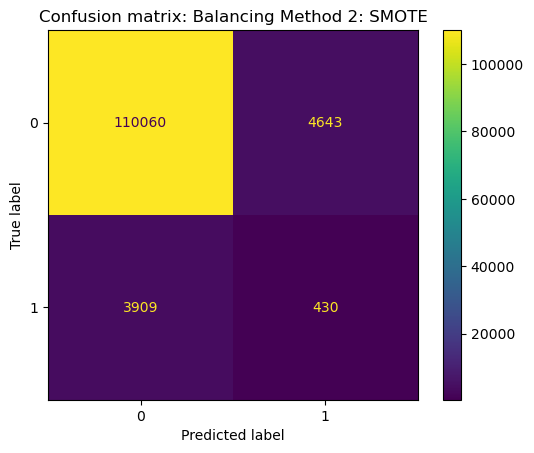

In [34]:
from sklearn.preprocessing import OrdinalEncoder
# clean SMOTE

from imblearn.over_sampling import SMOTE
smote = SMOTE(
    random_state=42,
    k_neighbors=3,
    sampling_strategy=0.5,
)
categorical_preprocess_smotenc = Pipeline([
    ('impute',    SimpleImputer(strategy='most_frequent')),
    ('ordinal',    OrdinalEncoder(handle_unknown='error'))
])
# custom preprocessing
preprocessSmotenc = ColumnTransformer([
    ('num', numeric_preprocess, num_cols),
    ('bin', 'passthrough', bin_cols),
    ('cat', categorical_preprocess_smotenc, cat_cols),
])
balancingB_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessSmotenc),
    ('smote', smote),
    ('clf', log_clf)
])

balancingB_auc = evaluate_pipeline(
    balancingB_pipeline,
    X_train, y_train,
    X_val, y_val,
    name="Balancing Method 2: SMOTE"
)

### SMOTE with default parameters


===== Evaluating: Balancing Method 2: SMOTE =====
Balancing Method 2: SMOTE ROC AUC: 0.6198
              precision    recall  f1-score   support

           0       0.97      0.60      0.75    114703
           1       0.05      0.57      0.09      4339

    accuracy                           0.60    119042
   macro avg       0.51      0.59      0.42    119042
weighted avg       0.94      0.60      0.72    119042



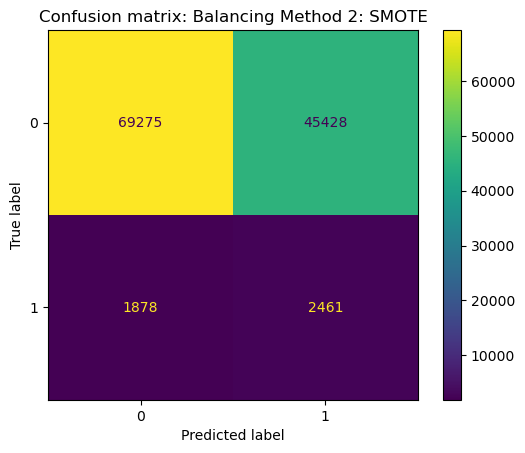

In [37]:
from sklearn.preprocessing import OrdinalEncoder
# clean SMOTE

from imblearn.over_sampling import SMOTE
smote = SMOTE(
    random_state=42,
)
categorical_preprocess_smotenc = Pipeline([
    ('impute',    SimpleImputer(strategy='most_frequent')),
    ('ordinal',    OrdinalEncoder(handle_unknown='error'))
])
# custom preprocessing
preprocessSmotenc = ColumnTransformer([
    ('num', numeric_preprocess, num_cols),
    ('bin', 'passthrough', bin_cols),
    ('cat', categorical_preprocess_smotenc, cat_cols),
])
balancingB_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessSmotenc),
    ('smote', smote),
    ('clf', log_clf)
])

balancingB_auc = evaluate_pipeline(
    balancingB_pipeline,
    X_train, y_train,
    X_val, y_val,
    name="Balancing Method 2: SMOTE"
)

## METHOD 6: SMOTE + ENN



===== Evaluating: Balancing Method 2: SMOTE ENN =====
Balancing Method 2: SMOTE ENN ROC AUC: 0.6204
              precision    recall  f1-score   support

           0       0.98      0.15      0.25    114703
           1       0.04      0.93      0.08      4339

    accuracy                           0.17    119042
   macro avg       0.51      0.54      0.16    119042
weighted avg       0.95      0.17      0.25    119042



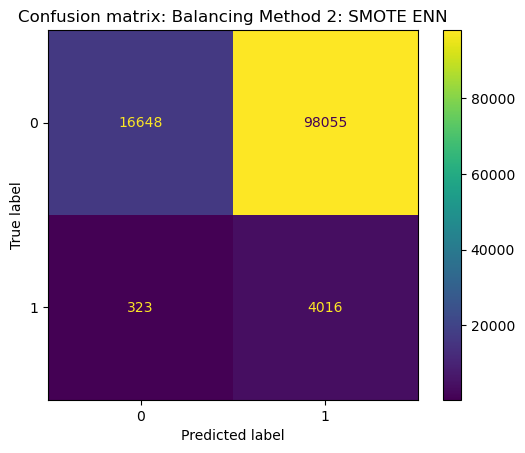

In [36]:
from sklearn.preprocessing import OrdinalEncoder
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.combine import SMOTEENN

# smote + enn
smoteenn = SMOTEENN(
    random_state=42
)

categorical_preprocess_smotenc = Pipeline([
    ('impute',    SimpleImputer(strategy='most_frequent')),
    ('ordinal',    OrdinalEncoder(handle_unknown='error'))
])
# custom preprocessing
preprocessSmotenc = ColumnTransformer([
    ('num', numeric_preprocess, num_cols),
    ('bin', 'passthrough', bin_cols),
    ('cat', categorical_preprocess_smotenc, cat_cols),
])
pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessSmotenc),
    ('smote', smoteenn),
    ('clf', log_clf)
])

output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="Balancing Method 2: SMOTE ENN"
)

## COMPARISON
I ran experiments on:
- Random Oversampling
- SMOTE + Tomek Links - which did not finish (took too long)
- SMOTE + Tomek Links with SMOTENC - which did not finish (took too much memory)
- SMOTENC - which did not finish (took too much memory)
- SMOTE with k_neighbors=3 and sampling_strategy=0.5
- SMOTE with default parameters
- SMOTE + ENN

**Random oversampling result**
```
===== Evaluating: Balancing Method 1: Random Oversampling =====
Balancing Method 1: Random Oversampling ROC AUC: 0.6362
              precision    recall  f1-score   support

           0       0.98      0.63      0.76    114703
           1       0.06      0.58      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.52      0.60      0.43    119042
weighted avg       0.94      0.62      0.74    119042

CONFUSION MATRIX:
71845   42858
1839    2500
```

**SMOTE with k_neighbors=3 and sampling_strategy=0.5 result**
```

===== Evaluating: Balancing Method 2: SMOTE =====
Balancing Method 2: SMOTE ROC AUC: 0.6202
              precision    recall  f1-score   support

           0       0.97      0.96      0.96    114703
           1       0.08      0.10      0.09      4339

    accuracy                           0.93    119042
   macro avg       0.53      0.53      0.53    119042
weighted avg       0.93      0.93      0.93    119042

CONFUSION MATRIX:
110060 4643
3903   430

```

**SMOTE with default parameters result**
```

===== Evaluating: Balancing Method 2: SMOTE =====
Balancing Method 2: SMOTE ROC AUC: 0.6198
              precision    recall  f1-score   support

           0       0.97      0.60      0.75    114703
           1       0.05      0.57      0.09      4339

    accuracy                           0.60    119042
   macro avg       0.51      0.59      0.42    119042
weighted avg       0.94      0.60      0.72    119042

CONFUSION MATRIX:
69275 45428
1878 2461

```
**SMOTE + ENN result**
```

===== Evaluating: Balancing Method 2: SMOTE ENN =====
Balancing Method 2: SMOTE ENN ROC AUC: 0.6204
              precision    recall  f1-score   support

           0       0.98      0.15      0.25    114703
           1       0.04      0.93      0.08      4339

    accuracy                           0.17    119042
   macro avg       0.51      0.54      0.16    119042
weighted avg       0.95      0.17      0.25    119042

CONFUSION MATRIX:
16648 98055
323 4016
```



  
**Methods:**

SMOTE balancing method is not the ideal to use in this instance becouse these methods work best for numerical and continuous features, but our dataset contains a lot of categorical and binary features which makes it harder for these methods to work properly.  

**Metrics:** 

Becouse our dataset is heavily unbalanced metrics like accuracy and precision and f1-score are not very useful for us. We will focus on AUC score and recall values.

**Results:**

Random oversampling gives much better results then no balancing method but still has a lof of false positives heavily categorize 0 instances as 1 which makes sense with our very unbalanced dataset and has a score around 0.6362 AUC score. Which we can see on recall values where for both 0 and 1 are around 0.6.

SMOTE with custo parameters categorize 1 values much worse then random oversampeling but improves with 0 values categorization which isnt much helpfull when our dataset is heavily populated with 0 values. AUC score is around 0.6202 which is worse. Which we can see on recall values where for 0 is around 0.96 but for 1 is only around 0.1.

SMOTE with defult parameters categorize values almost the same as Random oversampeling, but has worse AUC score around 0.6198.

SMOTE + ENN catagorize the 1 values the best of all methods but has much worse cateogirazation of 0 values where we have more FP when TN which is very bad outcome. Which we can see on recall values where for 0 is around 0.15 but for 1 is around 0.93.
 This method has AUC score around 0.6204 which is better then SMOTE methods but worse then Random oversampeling. 
 

**Conclusion:**

I will use the Random Oversampeling method becouse it has one of the best recalls which is much better then baseline and AUC score is the best of all methods.

**Possible improvements:**
Finetune the SMOTENC, SMOTENC with Tomak methods which could get a better results. Use different balancing method which would be better suited for our dataset. 


# 5. Feature transformations and engineering
Transform the features appropriately and prepare new ones (i.e., feature engineering) - focus on the increase in the model's performance (possibly in combination with further steps).

Some feature transformations are already applied in preprocessing step and cleaning steps:
- Numerical features: imputation with median and standard scaling
- Categorical features: imputation with most frequent value and one-hot encoding
- Binary features: passed through without changes
- replace -1 with NaN for easier handling of missing values
- removing columns with more then 50% missing values


TODO
- feature engeneering
    - mean of numerical values in group
    - count of binary 1 in group 
- make skew better with log1p transformation

## Feature engineering

I am creating these new features:
- Binary values
    - `custom_bin_1s_count`: count of 1s of all bin cols
    - `custom_bin_xind_1s_count`: count of 1s of xind bin cols
    - `custom_bin_xcalc_1s_count`: count of 1s of xcalc bin cols
- Numerical values
    - `custom_num_mean`: all numerical mean
    - `custom_num_std`: all numerical std
    - `custom_num_ind_mean`: xind cols numerical mean
    - `custom_num_reg_mean`: xreg cols numerical mean
    - `custom_num_car_mean`: xcar cols numerical mean
    - `custom_num_calc_mean`: xcalc cols numerical mean
    - `custom_num_ind_std`: xind cols numerical std
    - `custom_num_reg_std`: xreg cols numerical std
    - `custom_num_car_std`: xcar cols numerical std
    - `custom_num_calc_std`: xcalc cols numerical std 

Motivation was to create some new features which combine multiple exisiting features and can provide enough compression or representation of multiple features in one or some new practical inside. 

I am creating CustomPreprocessor which does the same thing as previus preprocessor which is:
- Numerical features: imputation with median and standard scaling
- Categorical features: imputation with most frequent value and one-hot encoding
- Binary features: passed through without changes

### UTILS

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin


class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Custom transformer for generating new engineered features.
    Safe for use inside sklearn or imblearn pipelines.
    """
    def __init__(self):
        # no parameters needed yet, but configurable if you want
        pass

    def fit(self, X, y=None):

        # find bin columns
        self.bin_cols_ = [c for c in X.columns if c.endswith('_bin')]
        # find numerical columns
        self.num_cols_ = [c for c in X.columns if c not in self.bin_cols_ and not c.endswith('_cat')]

        # get starts with xind and is bin
        self.xind_bin_cols_ = [c for c in self.bin_cols_ if c.startswith('xind') and c.endswith('_bin')]
        self.xcalc_bin_cols_ = [c for c in self.bin_cols_ if c.startswith('xcalc') and c.endswith('_bin')]

        # get numerical columns that start with ind, reg, car, calc
        self.ind_num_cols_ = [c for c in self.num_cols_ if c.startswith('xind') and not (c.endswith('_cat') or c.endswith('_bin'))]
        self.reg_num_cols_ = [c for c in self.num_cols_ if c.startswith('xreg') and not (c.endswith('_cat') or c.endswith('_bin'))]
        self.car_num_cols_ = [c for c in self.num_cols_ if c.startswith('xcar') and not (c.endswith('_cat') or c.endswith('_bin'))]
        self.calc_num_cols_ = [c for c in self.num_cols_ if c.startswith('xcalc') and not (c.endswith('_cat') or c.endswith('_bin'))]


        return self

    def transform(self, X):
        X_new = X.copy()

        # binary values
        # count of 1s of all bin cols
        X_new['custom_bin_1s_count'] = X_new[self.bin_cols_].sum(axis=1)
        # count of 1s of xind bin cols
        X_new['custom_bin_xind_1s_count'] = X_new[self.xind_bin_cols_].sum(axis=1)
        # count of 1s of xcalc bin cols
        X_new['custom_bin_xcalc_1s_count'] = X_new[self.xcalc_bin_cols_].sum(axis=1)

        # numerical values
        # all numerical mean
        X_new['custom_num_mean'] = X_new[self.num_cols_].mean(axis=1)
        # all numerical std
        X_new['custom_num_std'] = X_new[self.num_cols_].std(axis=1)
        # ind numerical mean
        X_new['custom_num_ind_mean'] = X_new[self.ind_num_cols_].mean(axis=1)
        X_new['custom_num_reg_mean'] = X_new[self.reg_num_cols_].mean(axis=1)
        X_new['custom_num_car_mean'] = X_new[self.car_num_cols_].mean(axis=1)
        X_new['custom_num_calc_mean'] = X_new[self.calc_num_cols_].mean(axis=1)
        # ind numerical std
        X_new['custom_num_ind_std'] = X_new[self.ind_num_cols_].std(axis=1)
        X_new['custom_num_reg_std'] = X_new[self.reg_num_cols_].std(axis=1)
        X_new['custom_num_car_std'] = X_new[self.car_num_cols_].std(axis=1)
        X_new['custom_num_calc_std'] = X_new[self.calc_num_cols_].std(axis=1)

        return X_new

# custom preprocess class
class CustomPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        X = X.copy()

        # Automatically detect column types AFTER feature dropping / engineering
        self.cat_cols_  = [c for c in X.columns if c.endswith('_cat')]
        self.bin_cols_  = [c for c in X.columns if c.endswith('_bin')]
        self.num_cols_  = [c for c in X.columns if c not in self.cat_cols_ + self.bin_cols_]

        # Build ColumnTransformer based on the *updated* columns
        self.preprocess_ = ColumnTransformer([
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), self.num_cols_),

            ('bin', 'passthrough', self.bin_cols_),

            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
            ]), self.cat_cols_)
        ])

        # Fit the actual preprocessors
        self.preprocess_.fit(X, y)
        return self

    def transform(self, X):
        X = X.copy()
        return self.preprocess_.transform(X)


### Feature engineering basic


===== Evaluating: Feature Engineering =====
Feature Engineering ROC AUC: 0.6359
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042



C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


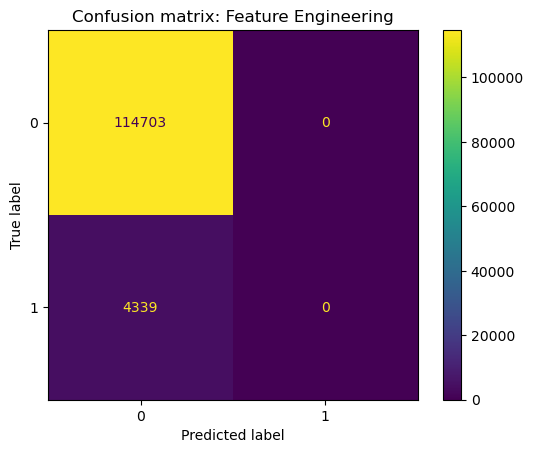

In [23]:

pipeline_fe = Pipeline([
    ('feature_engineer', FeatureEngineer()),
    ('preprocess', CustomPreprocessor()),
    ('clf', log_clf)
])

# evaluate feature engineering
fe_auc = evaluate_pipeline(
    pipeline_fe,
    X_train, y_train,
    X_val, y_val,
    name="Feature Engineering"
)

### Feature engineering with balancing


===== Evaluating: Feature Engineering with Balancing =====


C:\tools\Anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Feature Engineering with Balancing ROC AUC: 0.6365
              precision    recall  f1-score   support

           0       0.98      0.62      0.76    114703
           1       0.06      0.58      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.52      0.60      0.43    119042
weighted avg       0.94      0.62      0.74    119042



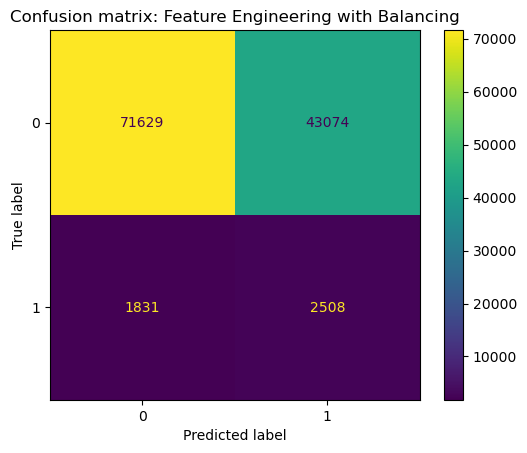

In [9]:
log_clf_custom = LogisticRegression(
    class_weight='balanced',
    solver='saga',
    max_iter = 500
)

pipeline = Pipeline([
    ('feature_engineer', FeatureEngineer()),
    ('preprocess', CustomPreprocessor()),
    ('clf', log_clf_custom)]
)

output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="Feature Engineering with Balancing"
)


===== Evaluating: Feature Engineering with Balancing =====
Feature Engineering with Balancing ROC AUC: 0.6365
              precision    recall  f1-score   support

           0       0.98      0.62      0.76    114703
           1       0.06      0.58      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.52      0.60      0.43    119042
weighted avg       0.94      0.62      0.74    119042



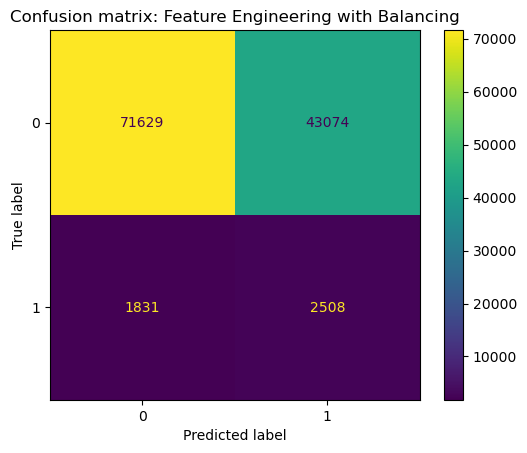

In [15]:
log_clf_custom = LogisticRegression(
    class_weight='balanced',
    solver='saga',
    max_iter = 500
)
    
pipeline = Pipeline([
    ('feature_engineer', FeatureEngineer()),
    ('preprocess', CustomPreprocessor()),
    ('clf', log_clf_custom)]
)

output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="Feature Engineering with Balancing"
)

### Baseline experiment


===== Evaluating: Feature Engineering with Balancing =====


C:\tools\Anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Feature Engineering with Balancing ROC AUC: 0.6361
              precision    recall  f1-score   support

           0       0.97      0.62      0.76    114703
           1       0.05      0.58      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.51      0.60      0.43    119042
weighted avg       0.94      0.62      0.74    119042



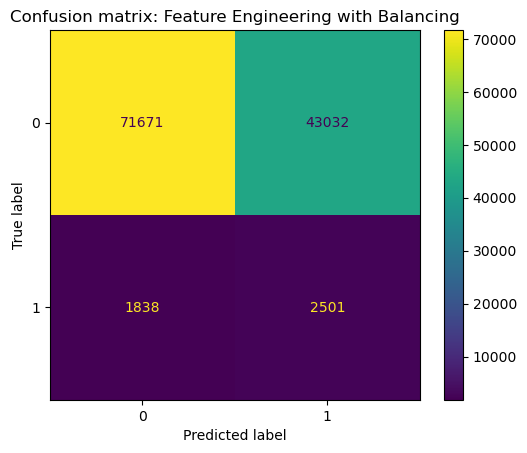

In [13]:
log_clf_custom = LogisticRegression(
    class_weight='balanced',
    solver='saga',
)

pipeline = Pipeline([
    ('preprocess', CustomPreprocessor()),
    ('clf', log_clf_custom)]
)

output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="Feature Engineering with Balancing"
)


===== Evaluating: Feature Engineering with Balancing =====
Feature Engineering with Balancing ROC AUC: 0.6361
              precision    recall  f1-score   support

           0       0.97      0.62      0.76    114703
           1       0.05      0.58      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.51      0.60      0.43    119042
weighted avg       0.94      0.62      0.74    119042



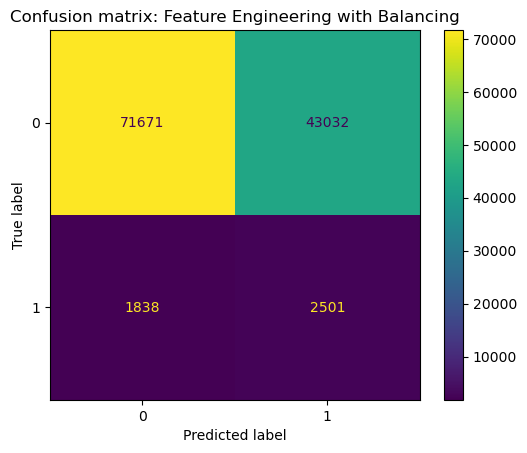

In [14]:
log_clf_custom = LogisticRegression(
    class_weight='balanced',
    solver='saga',
    max_iter = 500
)

pipeline = Pipeline([
    ('preprocess', CustomPreprocessor()),
    ('clf', log_clf_custom)]
)

output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="Feature Engineering with Balancing"
)

## COMPARISON
I am comparing Baseline experiment without Feature engeneering and Feature engineering with balancing both with settings max_iter=500 and class_weight='balanced' and solver='saga'.

**Baseline experiment result**
```

===== Evaluating: Baseline experiment =====
Feature Engineering with Balancing ROC AUC: 0.6361
              precision    recall  f1-score   support

           0       0.97      0.62      0.76    114703
           1       0.05      0.58      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.51      0.60      0.43    119042
weighted avg       0.94      0.62      0.74    119042


CONFUISON MATRIX:
71671 43032
1838 2501
```

**Feature engineering with balancing result**

```

===== Evaluating: Feature Engineering with Balancing =====
Feature Engineering with Balancing ROC AUC: 0.6365
              precision    recall  f1-score   support

           0       0.98      0.62      0.76    114703
           1       0.06      0.58      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.52      0.60      0.43    119042
weighted avg       0.94      0.62      0.74    119042


CONFUSION MATRIX:
71629 43074
1831 2508
```

We can see that the results are almost similiar even though we have an increase in AUC score around 0.0004 when using Feature engineering with balancing. There is also slight increase in precision but accuracy is probably almost the same.

# 6. Feature selection
Try to find some suitable subset of features - use at least two feature selection methods. Evaluate your choice on the validation set and discuss the influence. Do not use PCA (principal component analysis) in this step. Manual selection will not be accepted. 

I am running exeperiments in this section with:
- feature engineering
- standard preprocessing
- balancing with Random Oversampling

TODO
- RFECV
- L1 regularization
- _maybe
    - y log change 

## METHOD 1: RFECV

- results
    - with log_clf balanced - error memory
    - normal log_clf - error memory   
    - without feature engeneering - 
    - Log regressio(default setting) - doesnt konverge on max iter 

### Experiment 1:

In [ ]:
from sklearn.feature_selection import RFECV

log_clf_rfecv = LogisticRegression(
    solver='saga',
)


# RFECV configured
rfecv = RFECV(
    estimator=LogisticRegression(
        solver='saga',
    ),
    step=1,
    cv=5,
    scoring="roc_auc",
)

pipeline = Pipeline([
    ('feature_engineer', FeatureEngineer()),
    ('preprocess', CustomPreprocessor()),
    ('feature_selection', rfecv),
    ('clf', log_clf_rfecv)
])

# evalute
output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="RFECV"
)


===== Evaluating: RFECV =====


C:\tools\Anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\tools\Anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\tools\Anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\tools\Anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\tools\Anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\tools\Anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ di

### Experiment 2:


In [10]:
from sklearn import metrics
from sklearn.feature_selection import RFECV

def scorer(Y, yp):
    return np.sqrt(metrics.mean_squared_error(Y, yp))

# RFECV configured
rfecv = RFECV(
    estimator=LogisticRegression(),
    step=1,
    cv=5,
    scoring=metrics.make_scorer(scorer),
)

pipeline = Pipeline([
    ('feature_engineer', FeatureEngineer()),
    ('preprocess', CustomPreprocessor()),
    ('feature_selection', rfecv),
    ('clf', LogisticRegression())
])

# evalute
output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="RFECV"
)


===== Evaluating: RFECV =====


MemoryError: Unable to allocate 480. MiB for an array with shape (285701, 220) and data type float64


===== Evaluating: RFECV =====
RFECV ROC AUC: 0.5151
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042



C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


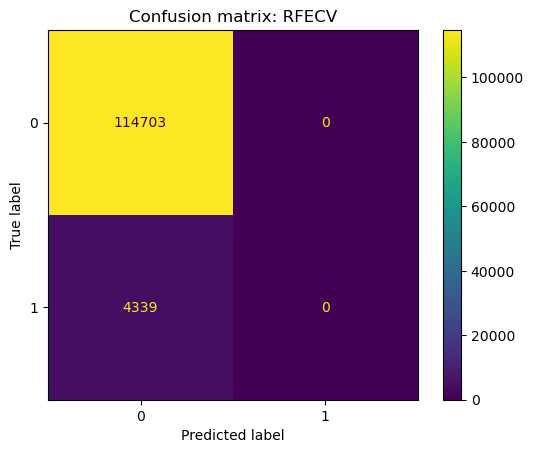

In [11]:
from sklearn import metrics
from sklearn.feature_selection import RFECV

def scorer(Y, yp):
    return np.sqrt(metrics.mean_squared_error(Y, yp))

# RFECV configured
rfecv = RFECV(
    estimator=LogisticRegression(),
    step=1,
    cv=5,
    scoring=metrics.make_scorer(scorer),
)

pipeline = Pipeline([
    ('preprocess', CustomPreprocessor()),
    ('feature_selection', rfecv),
    ('clf', LogisticRegression())
])

# evalute
output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="RFECV"
)


===== Evaluating: RFECV =====
RFECV ROC AUC: 0.5151
              precision    recall  f1-score   support

           0       0.97      0.58      0.73    114703
           1       0.04      0.45      0.07      4339

    accuracy                           0.58    119042
   macro avg       0.50      0.52      0.40    119042
weighted avg       0.93      0.58      0.70    119042



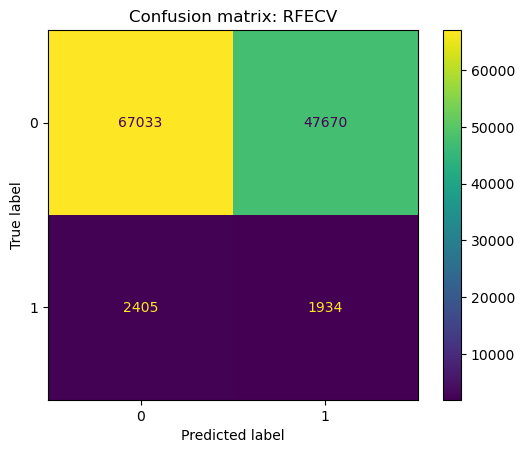

In [17]:
from sklearn import metrics
from sklearn.feature_selection import RFECV

def scorer(Y, yp):
    return np.sqrt(metrics.mean_squared_error(Y, yp))

# RFECV configured
rfecv = RFECV(
    estimator=LogisticRegression(),
    step=1,
    cv=5,
    scoring=metrics.make_scorer(scorer),
)

pipeline = Pipeline([
    ('preprocess', CustomPreprocessor()),
    ('feature_selection', rfecv),
    ('clf', LogisticRegression(class_weight='balanced'))
])

# evalute
output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="RFECV"
)

## METHOD 2: L1 regularization (Lasso)


===== Evaluating: L1 feature selection =====
L1 feature selection ROC AUC: 0.6365
              precision    recall  f1-score   support

           0       0.98      0.62      0.76    114703
           1       0.06      0.58      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.52      0.60      0.43    119042
weighted avg       0.94      0.62      0.74    119042



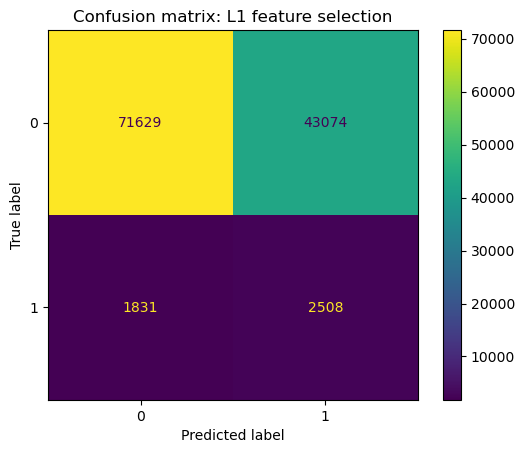

In [15]:


log_clf_balanced = LogisticRegression(
    n_jobs=-1,
    class_weight='balanced',
    solver='saga',
    max_iter=1000,
)


l1_selector = SelectFromModel(
    LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=5000,
        C=0.1   # tune between 0.01 and 1
    ),
    threshold='median'
)


pipeline = ImbPipeline(steps=[
    ('feature_engineer', FeatureEngineer()),
    ('preprocess', CustomPreprocessor()),
    ('feature_selection', l1_selector),
    ('clf', log_clf_balanced)
])

# evalute
output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="L1 feature selection"
)


===== Evaluating: L1 feature selection =====


C:\tools\Anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


L1 feature selection ROC AUC: 0.6361
              precision    recall  f1-score   support

           0       0.98      0.63      0.76    114703
           1       0.06      0.58      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.52      0.60      0.43    119042
weighted avg       0.94      0.62      0.74    119042



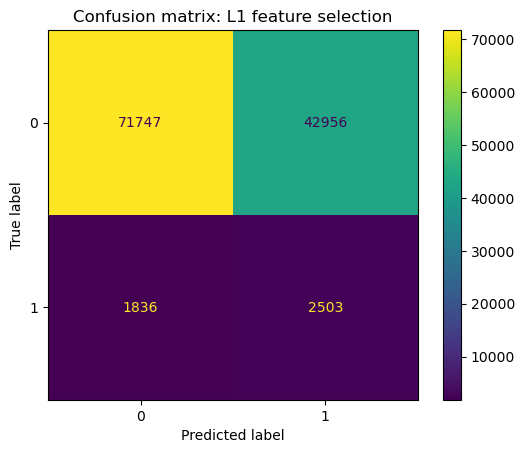

In [18]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

log_clf_balanced = LogisticRegression(
    class_weight='balanced',
)


l1_selector = SelectFromModel(
    LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=5000,
        C=0.1   # tune between 0.01 and 1
    ),
    threshold='median'
)


pipeline = ImbPipeline(steps=[
    ('preprocess', CustomPreprocessor()),
    ('feature_selection', l1_selector),
    ('clf', log_clf_balanced)
])

# evalute
output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="L1 feature selection"
)


===== Evaluating: L1 feature selection =====
L1 feature selection ROC AUC: 0.6360
              precision    recall  f1-score   support

           0       0.98      0.63      0.76    114703
           1       0.06      0.58      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.52      0.60      0.43    119042
weighted avg       0.94      0.62      0.74    119042



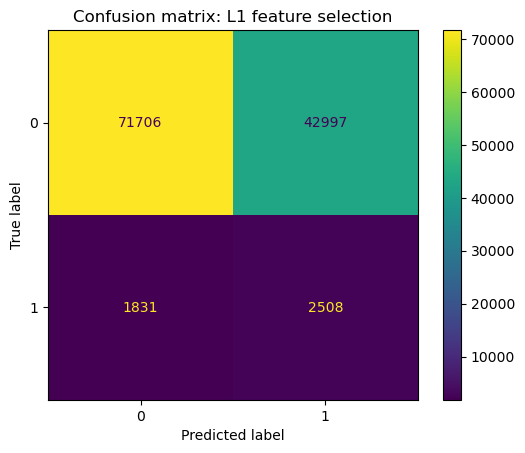

In [19]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

log_clf_balanced = LogisticRegression(
    class_weight='balanced',
    max_iter=500
)


l1_selector = SelectFromModel(
    LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=5000,
        C=0.1   # tune between 0.01 and 1
    ),
    threshold='median'
)


pipeline = ImbPipeline(steps=[
    ('preprocess', CustomPreprocessor()),
    ('feature_selection', l1_selector),
    ('clf', log_clf_balanced)
])

# evalute
output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="L1 feature selection"
)

## Baseline experiment


===== Evaluating: Baseline experiment =====
Baseline experiment ROC AUC: 0.6360
              precision    recall  f1-score   support

           0       0.98      0.63      0.76    114703
           1       0.06      0.58      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.52      0.60      0.43    119042
weighted avg       0.94      0.62      0.74    119042



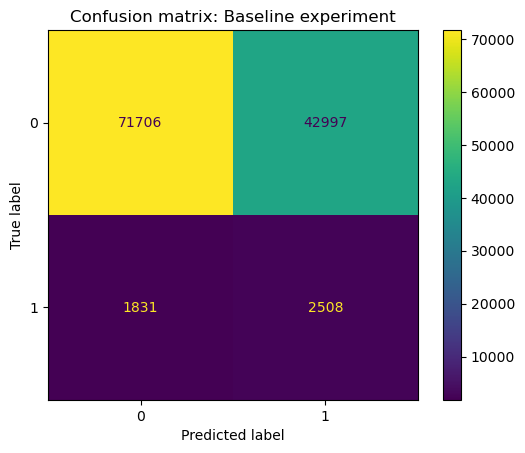

In [9]:
log_clf_custom = LogisticRegression(
    class_weight='balanced',
    max_iter = 500
)

pipeline = Pipeline([
    ('preprocess', CustomPreprocessor()),
    ('clf', log_clf_custom)]
)

output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="Baseline experiment"
)

## COMPARISON
I ran experiments on Feature selection with RFECV en L1 regularization (Lasso). Both with Logistic Regression in default settings with class_weight='balanced' and L1 with max_iter=500 becouse it havent converged with default settings and also with basic preprocessing without feature engeneering.

**Baseline experiment result**
```

===== Evaluating: Baseline experiment =====
Baseline experiment ROC AUC: 0.6360
              precision    recall  f1-score   support

           0       0.98      0.63      0.76    114703
           1       0.06      0.58      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.52      0.60      0.43    119042
weighted avg       0.94      0.62      0.74    119042


CONFUSION MATRIX:
71706 42997
1831 2508
```

**RFECV result**
```

===== Evaluating: RFECV =====
RFECV ROC AUC: 0.5151
              precision    recall  f1-score   support

           0       0.97      0.58      0.73    114703
           1       0.04      0.45      0.07      4339

    accuracy                           0.58    119042
   macro avg       0.50      0.52      0.40    119042
weighted avg       0.93      0.58      0.70    119042


CONFUSION MATRIX:
67033 47670
2405 1934
```

**L1 regularization (Lasso) result**
```

===== Evaluating: L1 feature selection =====
L1 feature selection ROC AUC: 0.6360
              precision    recall  f1-score   support

           0       0.98      0.63      0.76    114703
           1       0.06      0.58      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.52      0.60      0.43    119042
weighted avg       0.94      0.62      0.74    119042



CONFUSION MATRIX:
71706 42997
1831 2508
```

The RFECV has very bad AUC results much worse then baseline and L1 regularization (Lasso) which is almost the same as baseline results. We can also see that the accuraccy of RFECV compare to Baseline is worse same as precision for both 0 and 1. 

With L1 regularization we can see that we get exactly the same results in this number precision for all values so there isn't big influance and probably wont be used in the final experiment. The same even when we add an Feature engeneering before L1 feature selection.

# 7. Dimension reduction - PCA
Use PCA to reduce the dimensionality. Discuss the influence of the number of principal components.

In [20]:
from sklearn.decomposition import PCA

components_list = [5, 10, 20, 40, 80]
results = []

for n in components_list:
    pca = PCA(n_components=n, random_state=42)
    
    # pipeline
    
    ## preprocess with Custom processor
    data = CustomPreprocessor()
    data.fit(X_train, y_train)
    
    # process with pca
    data_pca = pca.fit_transform(data.transform(X_train))
    
    # run logistic regression
    result = log_clf.fit(data_pca, y_train)
    
    y_val_proba_pca = result.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_val_proba_pca)
    results.append((n, auc))
    print(f"psa variance ratio:{pca.explained_variance_ratio_}")
    print(f"n_components={n}, ROC AUC={auc:.4f}")

TypeError: PCA only support sparse inputs with the "arpack" solver, while "auto" was passed. See TruncatedSVD for a possible alternative.

In [19]:
from sklearn.decomposition import PCA, TruncatedSVD

pca_n = 5

pca = TruncatedSVD(
    n_components=pca_n,
    random_state=42
)

# pipeline
# 
# ## preprocess with Custom processor
custom_preprocessor = CustomPreprocessor()
custom_preprocessor.fit(X_train, y_train)
pca_data = custom_preprocessor.transform(X_train)

# process with pca


# set cells with Nan to 0
# helper: nastaví `NaN` na 0 pro pandas DataFrame i numpy array
def fill_nan_zero(arr):
    if isinstance(arr, pd.DataFrame):
        return arr.fillna(0).values
    arr = np.asarray(arr)
    return np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

pca_data = fill_nan_zero(pca_data)
X_val_edited = fill_nan_zero(X_val)

pca_data = pca.fit_transform(pca_data)
X_val_edited = pca.fit_transform(X_val_edited)
log_model = LogisticRegression()    
# run logistic regression
result = log_model.fit(pca_data, y_train)

y_val_proba_pca = result.predict_proba(X_val_edited)[:, 1]
auc = roc_auc_score(y_val, y_val_proba_pca)
print(f"psa variance ratio:{pca.explained_variance_ratio_}")
print(f"n_components={pca_n}, ROC AUC={auc:.4f}")

psa variance ratio:[0.8337808  0.08236787 0.02344458 0.0100503  0.00668302]
n_components=5, ROC AUC=0.4873


In [21]:
class CustomPreprocessorForPCA(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        X = X.copy()

        # Automatically detect column types AFTER feature dropping / engineering
        self.cat_cols_  = [c for c in X.columns if c.endswith('_cat')]
        self.bin_cols_  = [c for c in X.columns if c.endswith('_bin')]
        self.num_cols_  = [c for c in X.columns if c not in self.cat_cols_ + self.bin_cols_]

        # Build ColumnTransformer based on the *updated* columns
        self.preprocess_ = ColumnTransformer([
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), self.num_cols_),

            ('bin', 'passthrough', self.bin_cols_),

            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ]), self.cat_cols_)
        ])

        # Fit the actual preprocessors
        self.preprocess_.fit(X, y)
        return self

    def transform(self, X):
        X = X.copy()
        return self.preprocess_.transform(X)


===== Evaluating: PCA =====
PCA ROC AUC: 0.6005
              precision    recall  f1-score   support

           0       0.97      0.62      0.76    114703
           1       0.05      0.52      0.09      4339

    accuracy                           0.62    119042
   macro avg       0.51      0.57      0.43    119042
weighted avg       0.94      0.62      0.74    119042



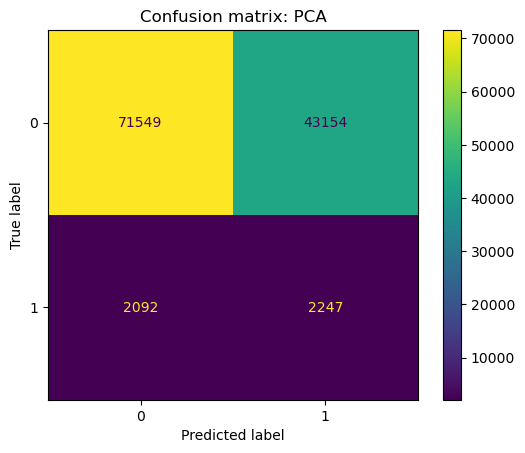

psa variance ratio:[0.08372537 0.05400848 0.04388898 0.03713933 0.0315671 ]


In [23]:
# use pipeline with pca
from sklearn.decomposition import PCA, TruncatedSVD
pca_n = 5
pca = PCA(
    n_components=pca_n,
    random_state=42
)
pipeline = Pipeline([
    ('preprocess', CustomPreprocessorForPCA()),
    ('pca', pca),
    ('clf', LogisticRegression(class_weight='balanced'))
])
# evalute
output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="PCA"
)
print(f"psa variance ratio:{pca.explained_variance_ratio_}")


===== Evaluating: PCA =====
PCA ROC AUC: 0.6005
              precision    recall  f1-score   support

           0       0.97      0.62      0.76    114703
           1       0.05      0.52      0.09      4339

    accuracy                           0.62    119042
   macro avg       0.51      0.57      0.43    119042
weighted avg       0.94      0.62      0.74    119042



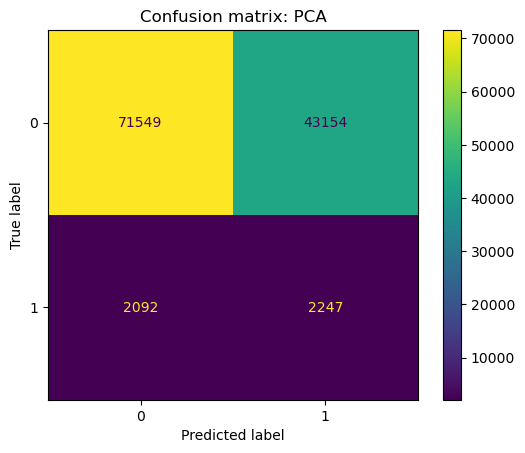

psa variance ratio:[0.08372537 0.05400848 0.04388898 0.03713933 0.0315671 ]

===== Evaluating: PCA =====
PCA ROC AUC: 0.6016
              precision    recall  f1-score   support

           0       0.97      0.62      0.76    114703
           1       0.05      0.52      0.09      4339

    accuracy                           0.62    119042
   macro avg       0.51      0.57      0.43    119042
weighted avg       0.94      0.62      0.74    119042



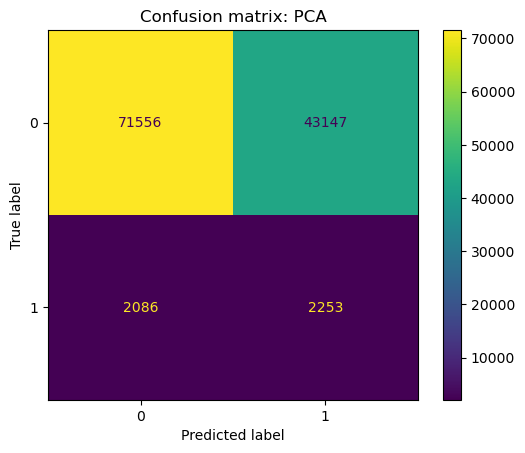

psa variance ratio:[0.08372537 0.05400861 0.04389874 0.03719089 0.03169615 0.02977793
 0.02969007 0.02965537 0.02962334 0.02953221]

===== Evaluating: PCA =====
PCA ROC AUC: 0.6019
              precision    recall  f1-score   support

           0       0.97      0.62      0.76    114703
           1       0.05      0.52      0.09      4339

    accuracy                           0.62    119042
   macro avg       0.51      0.57      0.42    119042
weighted avg       0.94      0.62      0.73    119042



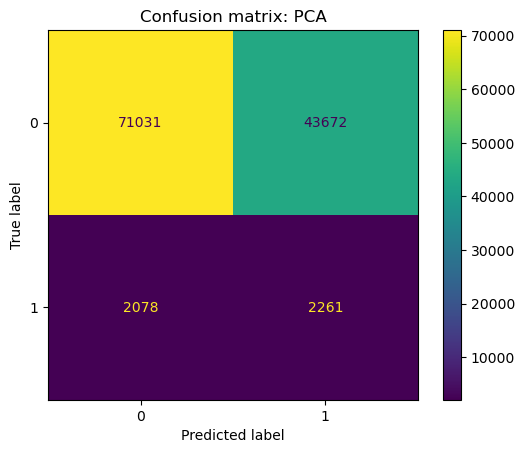

psa variance ratio:[0.08372537 0.05400903 0.04389994 0.03722513 0.03170021 0.02982365
 0.02970769 0.02966503 0.02962925 0.02958924 0.02956298 0.02949574
 0.0294798  0.0294622  0.02940698 0.02933867 0.02927954 0.02925858
 0.02922318 0.02916708]

===== Evaluating: PCA =====
PCA ROC AUC: 0.6145
              precision    recall  f1-score   support

           0       0.97      0.61      0.75    114703
           1       0.05      0.56      0.09      4339

    accuracy                           0.61    119042
   macro avg       0.51      0.58      0.42    119042
weighted avg       0.94      0.61      0.72    119042



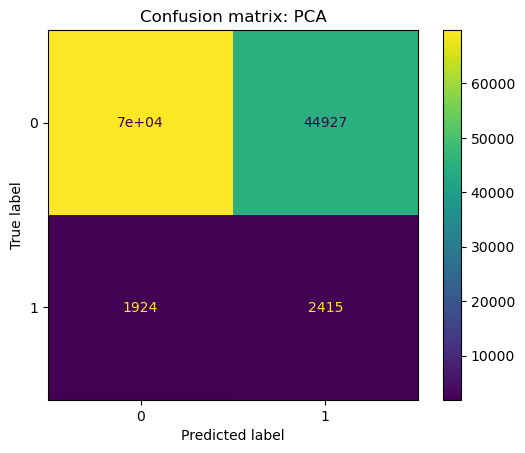

psa variance ratio:[0.08372537 0.05400903 0.04389994 0.03722513 0.03170021 0.02982365
 0.02970768 0.02966502 0.02962925 0.02958924 0.02956298 0.02949574
 0.0294798  0.0294622  0.02940698 0.02933867 0.02927953 0.02925858
 0.02922318 0.02916707 0.02556237 0.02487353 0.02203486 0.0162502
 0.01515428 0.01389034 0.00853687 0.0083664  0.00745471 0.00728516]

===== Evaluating: PCA =====
PCA ROC AUC: 0.6162
              precision    recall  f1-score   support

           0       0.97      0.61      0.75    114703
           1       0.05      0.56      0.09      4339

    accuracy                           0.60    119042
   macro avg       0.51      0.58      0.42    119042
weighted avg       0.94      0.60      0.72    119042



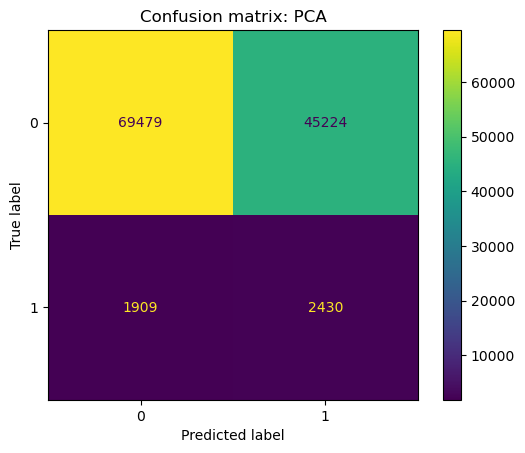

psa variance ratio:[0.08372537 0.05400903 0.04389994 0.03722513 0.03170021 0.02982365
 0.02970769 0.02966503 0.02962925 0.02958924 0.02956298 0.02949574
 0.0294798  0.0294622  0.02940698 0.02933867 0.02927954 0.02925858
 0.02922318 0.02916708 0.02556237 0.02487357 0.02203489 0.01625021
 0.01515437 0.01389043 0.00857418 0.00841054 0.00748769 0.00730947
 0.00728001 0.00701587 0.00688628 0.00685563 0.00669463 0.00640402
 0.0063775  0.00603413 0.00590458 0.00553527]

===== Evaluating: PCA =====
PCA ROC AUC: 0.6313
              precision    recall  f1-score   support

           0       0.97      0.62      0.76    114703
           1       0.05      0.56      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.51      0.59      0.43    119042
weighted avg       0.94      0.62      0.74    119042



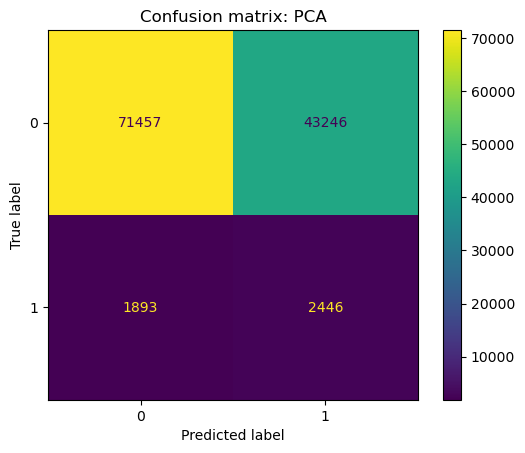

psa variance ratio:[0.08372537 0.05400903 0.04389994 0.03722513 0.03170021 0.02982365
 0.02970769 0.02966503 0.02962925 0.02958924 0.02956298 0.02949574
 0.0294798  0.0294622  0.02940698 0.02933867 0.02927954 0.02925858
 0.02922318 0.02916708 0.02556237 0.02487357 0.02203489 0.01625021
 0.01515437 0.01389043 0.00857423 0.00841066 0.00749039 0.00731303
 0.00728033 0.00701955 0.00688688 0.00685694 0.00669532 0.00641104
 0.00637847 0.00603449 0.00590778 0.0055497  0.00523176 0.00458202
 0.00406689 0.00383171 0.00382532 0.00353208 0.00339262 0.00335816
 0.00316569 0.0030402 ]


In [25]:
# we have 58 features

# use pipeline with pca
from sklearn.decomposition import PCA, TruncatedSVD

pca_n = [5, 10, 20, 30, 40, 50]

for n in pca_n:
    pca = PCA(
        n_components=n,
        random_state=42
    )
    pipeline = Pipeline([
        ('preprocess', CustomPreprocessorForPCA()),
        ('pca', pca),
        ('clf', LogisticRegression(class_weight='balanced'))
    ])
    # evalute
    output = evaluate_pipeline(
        pipeline,
        X_train, y_train,
        X_val, y_val,
        name="PCA"
    )
    print(f"psa variance ratio:{pca.explained_variance_ratio_}")

In [26]:
# we have 58 features

# use pipeline with pca
from sklearn.decomposition import PCA, TruncatedSVD



pca = PCA(
    random_state=42
)
pipeline = Pipeline([
    ('preprocess', CustomPreprocessorForPCA()),
    ('pca', pca),
    
])
output = pipeline.fit(
    X_train, y_train)

cum_var = np.cumsum(pca.explained_variance_ratio_)

# print cumulative variance ratio
print("Cumulative explained variance ratio:")
for i, var in enumerate(cum_var):
    print(f"Component {i+1}: {var:.4f}")
print(f"psa variance ratio:{pca.explained_variance_ratio_}")

Cumulative explained variance ratio:
Component 1: 0.0837
Component 2: 0.1377
Component 3: 0.1816
Component 4: 0.2189
Component 5: 0.2506
Component 6: 0.2804
Component 7: 0.3101
Component 8: 0.3398
Component 9: 0.3694
Component 10: 0.3990
Component 11: 0.4285
Component 12: 0.4580
Component 13: 0.4875
Component 14: 0.5170
Component 15: 0.5464
Component 16: 0.5757
Component 17: 0.6050
Component 18: 0.6343
Component 19: 0.6635
Component 20: 0.6926
Component 21: 0.7182
Component 22: 0.7431
Component 23: 0.7651
Component 24: 0.7814
Component 25: 0.7965
Component 26: 0.8104
Component 27: 0.8190
Component 28: 0.8274
Component 29: 0.8349
Component 30: 0.8422
Component 31: 0.8495
Component 32: 0.8565
Component 33: 0.8634
Component 34: 0.8702
Component 35: 0.8769
Component 36: 0.8834
Component 37: 0.8897
Component 38: 0.8958
Component 39: 0.9017
Component 40: 0.9072
Component 41: 0.9125
Component 42: 0.9170
Component 43: 0.9211
Component 44: 0.9249
Component 45: 0.9288
Component 46: 0.9323
Compon

We can see that we can have 40 components and still have around 90% of explained variance ratio.


===== Evaluating: PCA =====
PCA ROC AUC: 0.6162
              precision    recall  f1-score   support

           0       0.97      0.61      0.75    114703
           1       0.05      0.56      0.09      4339

    accuracy                           0.60    119042
   macro avg       0.51      0.58      0.42    119042
weighted avg       0.94      0.60      0.72    119042



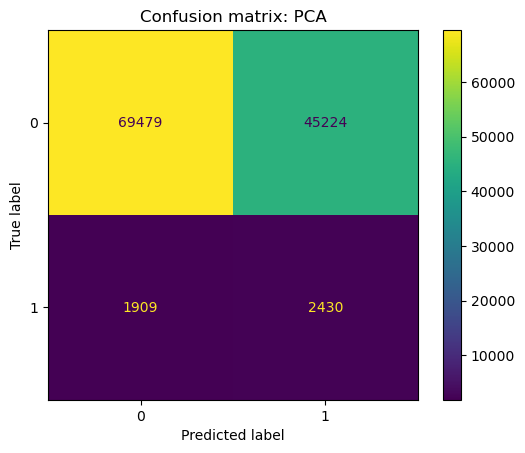

psa variance ratio:[0.08372537 0.05400903 0.04389994 0.03722513 0.03170021 0.02982365
 0.02970769 0.02966503 0.02962925 0.02958924 0.02956298 0.02949574
 0.0294798  0.0294622  0.02940698 0.02933867 0.02927954 0.02925858
 0.02922318 0.02916708 0.02556237 0.02487357 0.02203489 0.01625021
 0.01515437 0.01389043 0.00857418 0.00841054 0.00748769 0.00730947
 0.00728001 0.00701587 0.00688628 0.00685563 0.00669463 0.00640402
 0.0063775  0.00603413 0.00590458 0.00553527]


In [27]:
# we have 58 features

# use pipeline with pca
from sklearn.decomposition import PCA, TruncatedSVD

n = 40
pca = PCA(
    n_components=n,
    random_state=42
)
pipeline = Pipeline([
    ('preprocess', CustomPreprocessorForPCA()),
    ('pca', pca),
    ('clf', LogisticRegression(class_weight='balanced'))
])
# evalute
output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="PCA"
)
print(f"psa variance ratio:{pca.explained_variance_ratio_}")

## Baseline experiment


===== Evaluating: baseline =====
baseline ROC AUC: 0.6361
              precision    recall  f1-score   support

           0       0.98      0.63      0.76    114703
           1       0.06      0.58      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.52      0.60      0.43    119042
weighted avg       0.94      0.62      0.74    119042



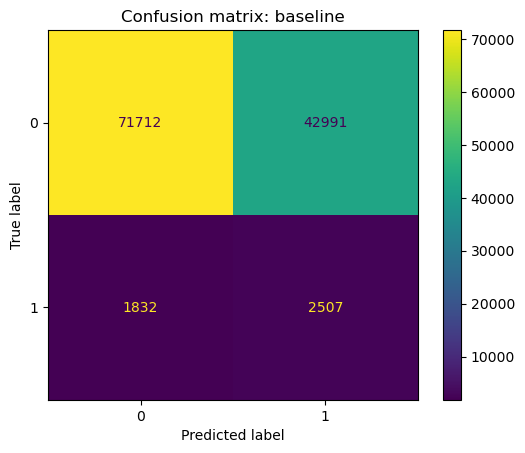

In [29]:
pipeline = Pipeline([
    ('preprocess', CustomPreprocessorForPCA()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=500))
])
# evalute
output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="baseline"
)

## COMPARISON
From the results we can see that PCA with 40 components doesnt have any positive influance on the result and the data are almost similar or worse. I dont think the reduction is worth losing AUC values and have better accuracy. 

# Final experiment tuning

### UTILS

In [9]:
class CustomImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        X = X.copy()

        # Automatically detect column types AFTER feature dropping / engineering
        self.cat_cols_  = [c for c in X.columns if c.endswith('_cat')]
        self.bin_cols_  = [c for c in X.columns if c.endswith('_bin')]
        self.num_cols_  = [c for c in X.columns if c not in self.cat_cols_ + self.bin_cols_]

        # Build ColumnTransformer based on the *updated* columns
        self.preprocess_ = ColumnTransformer([
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]), self.num_cols_),

            ('bin', 'passthrough', self.bin_cols_),

            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent'))
            ]), self.cat_cols_)
        ])

        # Fit the actual preprocessors
        self.preprocess_.fit(X, y)
        return self

    def transform(self, X):
        X = X.copy()
        return self.preprocess_.transform(X)


## Original data Experiment with simple imputer no balancing


===== Evaluating: Baseline Logistic Regression =====
Baseline Logistic Regression ROC AUC: 0.6278
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042



C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


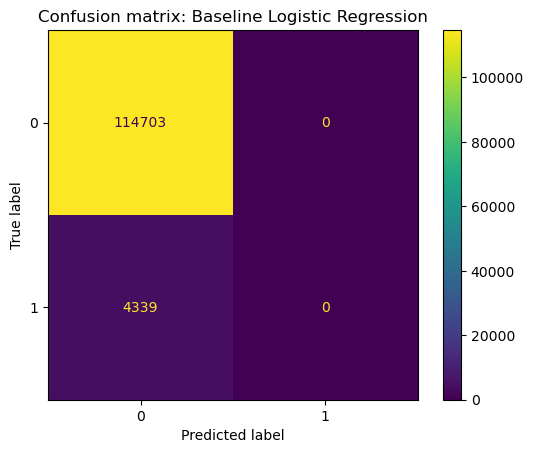

In [33]:


baseline_pipe = Pipeline([
    ('preprocess', CustomImputer()),
    ('clf', LogisticRegression(max_iter=2000))
])

# evaluate baseline model
baseline_auc = evaluate_pipeline(
    baseline_pipe,
    X_train, y_train,
    X_val, y_val,
    name="Baseline Logistic Regression"
)

We can see that with simple imputer and no balancing the model doesnt categorize any values with 1 and has AUC score around 0.62 which is expected.

## Original data Experiment with standard preprocessing and no balancing


===== Evaluating: Baseline Logistic Regression =====
Baseline Logistic Regression ROC AUC: 0.6359
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042



C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


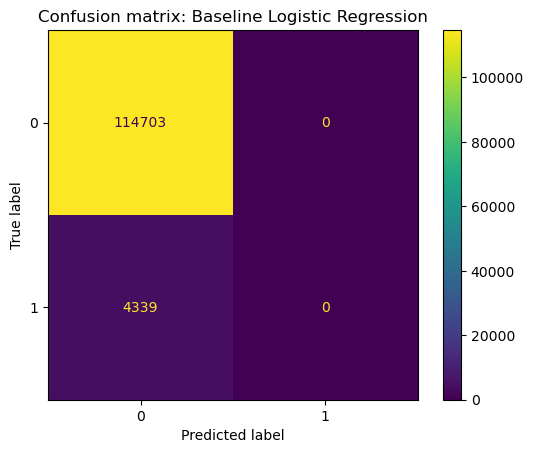

In [34]:

baseline_pipe = Pipeline([
    ('preprocess', CustomPreprocessor()),
    ('clf', LogisticRegression(max_iter=2000))
])

# evaluate baseline model
baseline_auc = evaluate_pipeline(
    baseline_pipe,
    X_train, y_train,
    X_val, y_val,
    name="Baseline Logistic Regression"
)

We can see that with scaling and normalizing the model improves a bit and has AUC score around 0.63 but still doesnt categorize any values with 1.


===== Evaluating: Binning Method 2: Equal-frequency binning =====


C:\tools\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\tools\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\tools\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\tools\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\tools\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: 

Binning Method 2: Equal-frequency binning ROC AUC: 0.6400
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042



C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


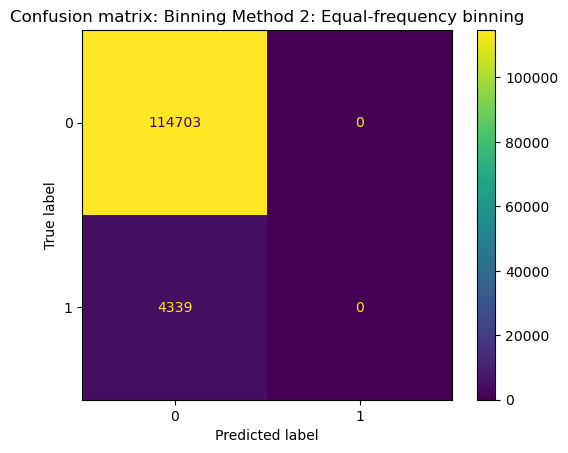

In [37]:
# custom preprocess class
class CustomPreprocessorWithBinning(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        X = X.copy()

        # Automatically detect column types AFTER feature dropping / engineering
        self.cat_cols_  = [c for c in X.columns if c.endswith('_cat')]
        self.bin_cols_  = [c for c in X.columns if c.endswith('_bin')]
        self.num_cols_  = [c for c in X.columns if c not in self.cat_cols_ + self.bin_cols_]

        # Build ColumnTransformer based on the *updated* columns
        self.preprocess_ = ColumnTransformer([
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('bins', KBinsDiscretizer(n_bins=15, encode='onehot-dense', strategy='quantile')),
                ('scaler', StandardScaler())
            ]), self.num_cols_),

            ('bin', 'passthrough', self.bin_cols_),

            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
            ]), self.cat_cols_)
        ])

        # Fit the actual preprocessors
        self.preprocess_.fit(X, y)
        return self

    def transform(self, X):
        X = X.copy()
        return self.preprocess_.transform(X)

binning_B_pipe = Pipeline([
    ('preprocess', CustomPreprocessorWithBinning()),
    ('clf', LogisticRegression(max_iter=2000))
])
# evaluate binning method 2
binning_B_auc = evaluate_pipeline(
    binning_B_pipe,
    X_train, y_train,
    X_val, y_val,
    name="Binning Method 2: Equal-frequency binning"
)

## Only simple preprocess + balancing


===== Evaluating: Simple Preprocess + Balancing =====
Simple Preprocess + Balancing ROC AUC: 0.6362
              precision    recall  f1-score   support

           0       0.98      0.63      0.76    114703
           1       0.06      0.58      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.52      0.60      0.43    119042
weighted avg       0.94      0.62      0.74    119042



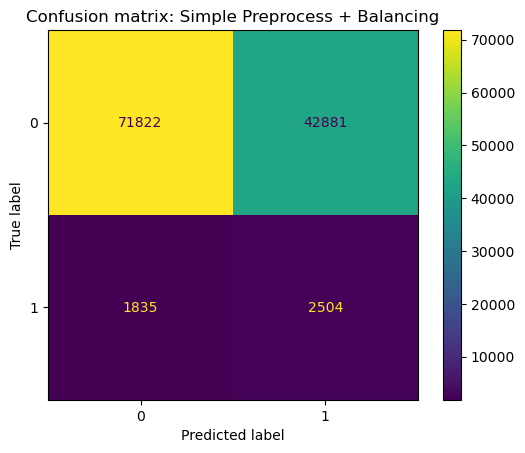

In [41]:

pipeline = ImbPipeline(steps=[
    ('preprocess', CustomPreprocessor()),
    ('balancing', RandomOverSampler(random_state=42)),
    ('clf', LogisticRegression(max_iter=2000))
])
# evaluate binning method 2
output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="Simple Preprocess + Balancing"
)

Even though the AUC value is very similar to previous experiments we can see that now the model categorizes some values with 1 and has much better recall values for class 1. But still not great considiring recall is for both classes around 0.6.

## All best methods
I choose to not use the binnig methods or PCA becouse they didnt improve the results in any way.


===== Evaluating: All best methods =====
All best methods ROC AUC: 0.6368
              precision    recall  f1-score   support

           0       0.98      0.63      0.76    114703
           1       0.06      0.58      0.10      4339

    accuracy                           0.62    119042
   macro avg       0.52      0.60      0.43    119042
weighted avg       0.94      0.62      0.74    119042



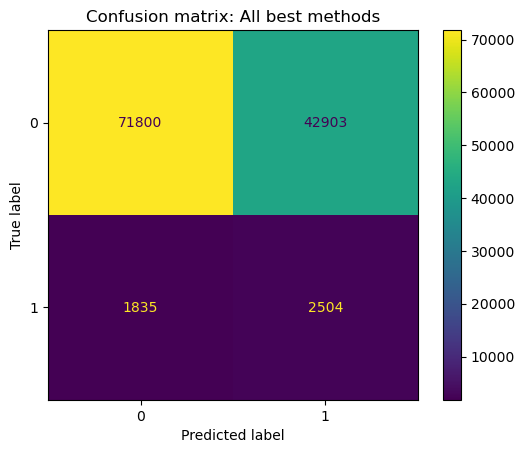

In [10]:
l1_selector = SelectFromModel(
    LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=5000,
        C=0.1   # tune between 0.01 and 1
    ),
    threshold='median'
)

pipeline = ImbPipeline(steps=[
    ('feature_engineer', FeatureEngineer()),
    ('preprocess', CustomPreprocessor()),
    ('feature_selection', l1_selector),
    ('balancing', RandomOverSampler(random_state=42)),
    ('clf', LogisticRegression(max_iter=2000))
])
# evaluate binning method 2
output = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_val, y_val,
    name="All best methods"
)

We can see that even with all the best methods used in previus sections the reults are not much better for precision or recall for both values. The only thing that improved is the AUC value but increase is very small around 0.001. Becouse L1 feature selection doesnt add much better results as we see from previus section and is computation heavy i will not be used in final experiment.

# FINAL EXPERIMENTS

## Original data Experiment with simple imputer no balancing final


===== Evaluating: Final Baseline Logistic Regression =====
Final Baseline Logistic Regression ROC AUC: 0.6172
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114704
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119043
   macro avg       0.48      0.50      0.49    119043
weighted avg       0.93      0.96      0.95    119043



C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\tools\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


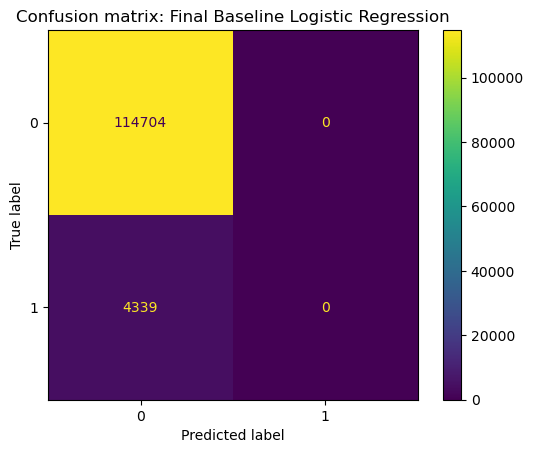

In [17]:
baseline_pipe = Pipeline([
    ('preprocess', CustomImputer()),
    ('clf', LogisticRegression(max_iter=2000))
])

# evaluate baseline model
baseline_output_final, y_pred_proba, y_pred  = evaluate_pipeline(
    baseline_pipe,
    X_train, y_train,
    X_test, y_test,
    name="Final Baseline Logistic Regression"
)

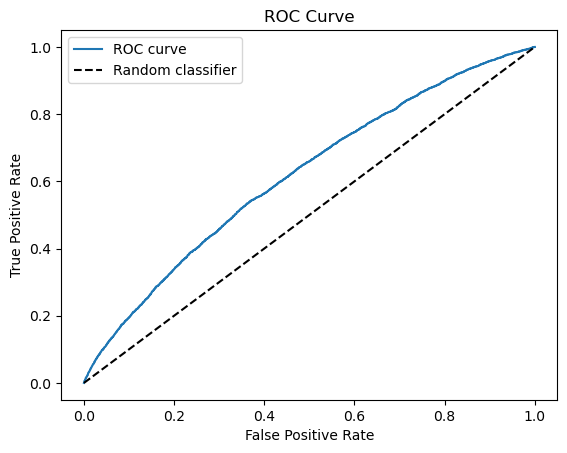

In [20]:
from sklearn.metrics import roc_curve

# 1) Compute FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)


# 3) Plot
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [10]:
from sklearn.metrics import roc_curve

# 1) Compute FPR, TPR, and thresholds
y_val_pred_proba = baseline_output_final.predict_proba(X_val)[:, 0]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)


# 3) Plot
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

NameError: name 'baseline_output_final' is not defined

## All best methods final experiment


===== Evaluating: All best methods =====
All best methods ROC AUC: 0.6261
              precision    recall  f1-score   support

           0       0.97      0.63      0.76    114704
           1       0.05      0.55      0.10      4339

    accuracy                           0.63    119043
   macro avg       0.51      0.59      0.43    119043
weighted avg       0.94      0.63      0.74    119043



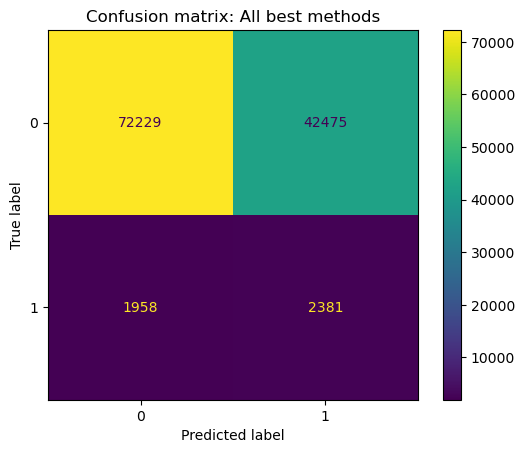

In [14]:
pipeline = ImbPipeline(steps=[
    ('feature_engineer', FeatureEngineer()),
    ('preprocess', CustomPreprocessor()),
    ('balancing', RandomOverSampler(random_state=42)),
    ('clf', LogisticRegression(max_iter=2000))
])
# evaluate binning method 2
all_best_output, y_pred_proba, y_pred  = evaluate_pipeline(
    pipeline,
    X_train, y_train,
    X_test, y_test,
    name="All best methods"
)

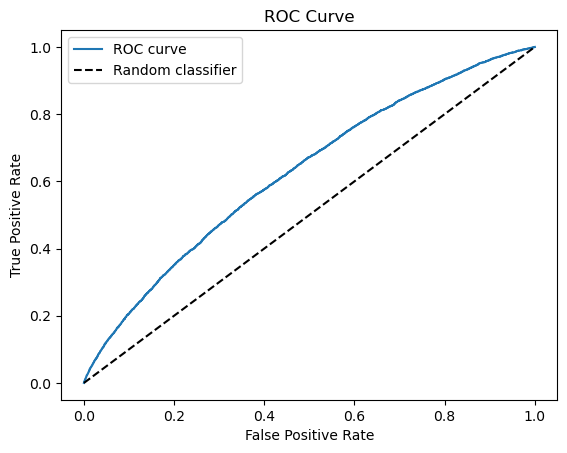

In [16]:
from sklearn.metrics import roc_curve

# 1) Compute FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 3) Plot
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## CONCLUSION
On the final data we can see the same thing as with validation data in section above. The biggest difference makes an balancing preprocessing step becouse our dataset is heavily unbalanced. So even thou with all best methods we dont get much better AUC values about 0.01 increase. Which is similiar on ROC curves where these two looks almost the same. We can see that the recall for class 1 improved a lot from around 0.1 to almost 0.6 which is a huge improvement. But still the results for prediciting with our classifer for our dataset arent much better, then random guessing. 

Better classifer or better choice of preprocessing steps could improve the results and also spending more time in cleaning part and removing outliers, also fine tuning specific methods could help.
